### **Note: This notebook uses the full 2022 BRFSS dataset, which is substantially larger than the NHANES datasets used in previous notebooks. As a result, the notebook may take several minutes to fully run and load all outputs.**
#### **Estimated runtime: approximately 3-5 minutes**

# **External Validation: Air Quality and Cognitive Impairment Across U.S. States (BRFSS + EPA AQI 2022)**

### CS 210: Data Management for Data Science

**Student:** Hemadharshinii Sendhilvel\
**NetID:** hs1244

--- 

## **Introduction**

This notebook extends the analysis of cognitive function and environmental exposure to an **external population-level validation dataset.**

Unlike previous notebooks that focused on:
- individual-level prediction (NHANES)
- temporal population trends (NHANES cycles + AQI)
  
this analysis evaluates whether state-level variation in air quality is associated with reported cognitive impairment using an independent dataset.

We use:
- Behavioral Risk Factor Surveillance System (BRFSS) survey data
- EPA Air Quality Index (AQI) data

This notebook serves as an external validation step within the broader project narrative:
> examining how environmental exposure and health factors relate to cognitive outcomes across multiple levels of analysis.

### **Research Question**
> Do U.S. states with higher air pollution levels report higher rates of cognitive impairment?

This analysis is observational, ecological (state-level), and exploratory (not causal).

---

## **Imports & Setup**

In [1]:
# data handling
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# database 
import sqlite3

# machine learning
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# evaluation metrics
from sklearn.metrics import accuracy_score

# style
sns.set(style = "whitegrid")

# database connection
# conn = sqlite3.connect("nhanes.db")

---

## **Data Sources**

This analysis uses:

### BRFSS (Cognitive Health Proxy)
We use:
- `CIMEMLOS`: self-reported cognitive difficulty
- demographic variables
- behavioral and health indicators

This cognitive outcome is converted into:
- 1 = reported cognitive difficulty
- 0 = no reported difficulty

This represents **self-reported cognitive impairment proxy** rather than a clinical diagnosis.

### EPA Air Quality Data
We use:
- daily AQI values from EPA monitoring stations
- aggregated to state-level yearly averages

AQI represents:
- lower values = better air quality
- higher values = worse air quality

AQI serves as a population-level environmental exposure indicator.

---

## **BRFSS Data Cleaning**

In [2]:
# read dataset
df = pd.read_sas("../data/raw/brfss/LLCP2022.XPT")

# keep relevant columns
cols = [
    "_STATE", "CIMEMLOS",
    "_AGEG5YR", "EDUCA",
    "_BMI5", "SMOKE100", "DIABETE4"
]
df = df[cols]

# rename columns for clarity
df = df.rename(columns = {
    "_STATE": "state_fips",
    "CIMEMLOS": "cognitive_decline",
    "_AGEG5YR": "age_group",
    "EDUCA": "education_level",
    "_BMI5": "bmi",
    "SMOKE100": "smoked_100",
    "DIABETE4": "diabetes_status"
})


# keep valid responses only
df = df[df["cognitive_decline"].isin([1,2])]

# binary outcome
df["cognitive_decline"] = df["cognitive_decline"].map({
    1: 1, 
    2: 0
})

# preview cleaned data
display(df.head())

,state_fips,cognitive_decline,age_group,education_level,bmi,smoked_100,diabetes_status
63190,12.0,1,12.0,6.0,1953.0,2.0,1.0
63191,12.0,0,9.0,6.0,3109.0,1.0,3.0
63192,12.0,1,12.0,6.0,NaN,2.0,3.0
63193,12.0,0,13.0,6.0,2439.0,1.0,3.0
63194,12.0,0,10.0,6.0,3228.0,2.0,3.0


### **State Mapping**

BRFSS stores states using FIPS codes, while EPA AQI data uses state names.\
To align datasets, we map state FIPS values to state names.

In [3]:
state_map = {
    12: "Florida",
    16: "Idaho",
    18: "Indiana",
    23: "Maine",
    41: "Oregon",
    44: "Rhode Island",
    45: "South Carolina",
    49: "Utah",
    50: "Vermont",
    51: "Virginia",
    55: "Wisconsin"
}

df["state_name"] = df["state_fips"].astype(int).map(state_map)

# check mapping
display(df.head())

,state_fips,cognitive_decline,age_group,education_level,bmi,smoked_100,diabetes_status,state_name
63190,12.0,1,12.0,6.0,1953.0,2.0,1.0,Florida
63191,12.0,0,9.0,6.0,3109.0,1.0,3.0,Florida
63192,12.0,1,12.0,6.0,NaN,2.0,3.0,Florida
63193,12.0,0,13.0,6.0,2439.0,1.0,3.0,Florida
63194,12.0,0,10.0,6.0,3228.0,2.0,3.0,Florida


---

## **AQI Data Processing**

In [4]:
# load dataset
aqi = pd.read_csv("../data/raw/epa/daily_aqi_by_county_2022.csv")

# select relevant columns:
# - state name: needed for geographic grouping
# - date: needed for time aggregation
# - aqi: main pollution metric

aqi = aqi[["State Name", "Date", "AQI"]]

# rename columns for clarity

aqi = aqi.rename(columns = {
    "State Name": "state",
    "Date": "date",
    "AQI": "aqi"
})

# convert date column
aqi["date"] = pd.to_datetime(aqi["date"])

# extract year for aggregation
aqi["year"] = aqi["date"].dt.year

# ensure that all data points are from the year 2022
aqi = aqi[aqi["year"] == 2022]

# handle missing values (drop rows missing aqi)
aqi = aqi.dropna(subset = ["aqi"])

# final check
print("Cleaned AQI Data:\n")
display(aqi.head())

Cleaned AQI Data:



,state,date,aqi,year
0,Alabama,2022-01-02,29,2022
1,Alabama,2022-01-05,48,2022
2,Alabama,2022-01-08,47,2022
3,Alabama,2022-01-11,21,2022
4,Alabama,2022-01-14,56,2022


### **State-Level AQI Aggregation**

We aggregate county-level AQI measurements into yearly state averages.

In [5]:
aqi_state = (
    aqi.groupby("state")
    .agg(avg_aqi = ("aqi", "mean"))
    .reset_index()
)

# preview aggregated AQI
display(aqi_state.head())

,state,avg_aqi
0,Alabama,42.281485
1,Alaska,30.096080
2,Arizona,48.006356
3,Arkansas,41.867128
4,California,56.145455


---

## **Merge BRFSS & AQI**

We merge:
- BRFSS respondent-level cognitive data
- state-level AQI averages

using state names as the merge key.

In [6]:
# merge both datasets
merged = df.merge(
    aqi_state,
    left_on = "state_name",
    right_on = "state",
    how = "left"
)

# check merged dataset
display(merged.head())

,state_fips,cognitive_decline,age_group,education_level,bmi,smoked_100,diabetes_status,state_name,state,avg_aqi
0,12.0,1,12.0,6.0,1953.0,2.0,1.0,Florida,Florida,41.666093
1,12.0,0,9.0,6.0,3109.0,1.0,3.0,Florida,Florida,41.666093
2,12.0,1,12.0,6.0,NaN,2.0,3.0,Florida,Florida,41.666093
3,12.0,0,13.0,6.0,2439.0,1.0,3.0,Florida,Florida,41.666093
4,12.0,0,10.0,6.0,3228.0,2.0,3.0,Florida,Florida,41.666093


---

## **State-Level Summary**

We compute:
- average cognitive impairment rate by state
- corresponding average AQI

In [17]:
state_summary = (
    merged.groupby("state_name")
    .agg(
        cognitive_rate = ("cognitive_decline", "mean"),
        avg_aqi = ("avg_aqi", "first")
    )
    .reset_index()
)

# convert proportion to percentage
state_summary["cognitive_rate"] *= 100

state_summary.to_csv("state_summary.csv", index=False)

# preview summary
display(state_summary)

,state_name,cognitive_rate,avg_aqi
0,Florida,12.683238,41.666093
1,Idaho,11.107711,38.931561
2,Indiana,10.854729,41.776891
3,Maine,10.067903,34.943419
4,Oregon,11.664565,39.514784
5,Rhode Island,11.594203,37.037071
6,South Carolina,11.249006,42.172330
7,Utah,11.369359,47.678227
8,Vermont,9.964912,38.205832
9,Virginia,10.067010,35.754477


---

## **Visualization: AQI vs Cognitive Impairment**

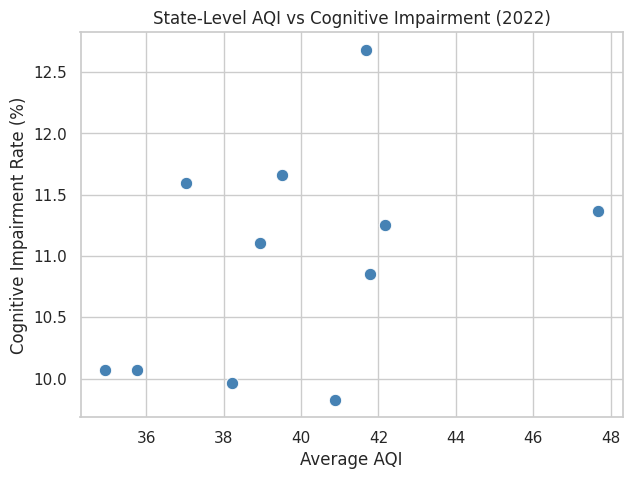

In [8]:
plt.figure(figsize = (7,5))

sns.scatterplot(
    data = state_summary,
    x = "avg_aqi",
    y = "cognitive_rate",
    color = "steelblue",
    s = 80
)

plt.title("State-Level AQI vs Cognitive Impairment (2022)")
plt.xlabel("Average AQI")
plt.ylabel("Cognitive Impairment Rate (%)")

plt.show()

### **Interpretation**

The relationship between AQI and cognitive impairment appears weak and scattered.

While some states with higher AQI exhibit slightly higher cognitive impairment rates, there is no strong linear pattern across observations.

This suggests:
- environmental exposure may contribute modestly
- demographic and health factors likely play larger roles
- state-level aggregation masks substantial individual variation

These findings are consistent with expectations for ecological, cross-sectional data.

---

## **Modeling Approach**

We model cognitive impairment as a function of:
- environmental exposure (AQI)
- demographic variables
- behavioral and health indicators

The goal is not strong prediction accuracy, but exploratory evaluation of whether AQI contributes a meaningful signal alongside other predictors.

### **Data Preparation for Modeling**

Before training machine learning models, we handle missing values in predictor variables. 

Some BRFSS variables, particularly BMI, contain missing observations. Since most scikit-learn models do not accept missing values directly, we impute missing numeric values using median values.

In [9]:
# modeling features 
features = ["avg_aqi", "age_group", "education_level", "bmi", "smoked_100", "diabetes_status"]

# predictors and target variable
X = merged[features]
y = merged["cognitive_decline"]

# impute missing values
imputer = SimpleImputer(strategy = "median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns = features
)

# preview processed features
display(X.head())

,avg_aqi,age_group,education_level,bmi,smoked_100,diabetes_status
0,41.666093,12.0,6.0,1953.0,2.0,1.0
1,41.666093,9.0,6.0,3109.0,1.0,3.0
2,41.666093,12.0,6.0,2746.0,2.0,3.0
3,41.666093,13.0,6.0,2439.0,1.0,3.0
4,41.666093,10.0,6.0,3228.0,2.0,3.0


### **Train-Test Split**

We divide the dataset into:
- 80% training data
- 20% testing data

This allows model evaluation on unseen observations.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

### **Model 1: Logistic Regression**
Logistic regression provides a baseline probabilistic classification model.

In [11]:
# logistic regression model
log_model = LogisticRegression(max_iter = 1000)
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### **Model 2: Decision Tree Classifier**
Decision trees capture nonlinear relationships and interaction effects between predictors.

In [12]:
# decision tree classifier
tree_model = DecisionTreeClassifier(
    max_depth = 5,
    random_state = 42
)
tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

### **Model 3: Random Forest Classifier**
Random forests combine multiple decision trees to improve stability and reduce overfitting.

In [13]:
# random forest classifier
rf_model = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### **Model Evaluation**
We evaluate all models using classification accuracy on the held-out test dataset.

In [14]:
# evaluate models
models = {
    "Logistic Regression": log_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

# print accuracy for each model
for name, model in models.items():
    # predictions
    preds = model.predict(X_test)
    # accuracy
    acc = accuracy_score(y_test, preds)

    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.8856
Decision Tree Accuracy: 0.8855
Random Forest Accuracy: 0.8509


#### **Interpretation of Model Performance**

All three classification models achieved relatively high accuracy:
- Logistic Regression: 88.56%
- Decision Tree: 88.55%
- Random Forest: 85.09%

The similar performance across models suggests that the relationship between the predictors and reported cognitive impairment is relatively stable and may not require highly complex nonlinear modeling.

However, these results should be interpreted cautiously:
- the BRFSS dataset is imbalanced, with most respondents reporting no cognitive impairment
- high overall accuracy may partially reflect the dominance of the majority class
- state-level AQI alone is unlikely to strongly predict individual cognitive impairment outcomes
- demographic and health variables (age, education, diabetes status, smoking behavior, BMI) likely contribute more substantially to model performance

Importantly, this notebook is not intended to build a clinical prediction model.\
Instead, it serves as an exploratory external validation of the broader project narrative: that environmental exposure may relate to cognitive health patterns at the population level.

#### **Checking BRFSS Dataset Balance**

In [15]:
# check target balance
target_counts = merged["cognitive_decline"].value_counts()

print(target_counts)

# proportions
print("\nProportions:\n")
print(merged["cognitive_decline"].value_counts(normalize = True))

cognitive_decline
0    56945
1     7003
Name: count, dtype: int64

Proportions:

cognitive_decline
0    0.890489
1    0.109511
Name: proportion, dtype: float64


### **Feature Importance** (Random Forest)
Random forests provide estimates of feature importance, allowing us to examine which variables contribute most strongly to predictions of cognitive impairment.\
This helps contextualize the relative influence of environmental exposure compared with demographic and health-related factors.

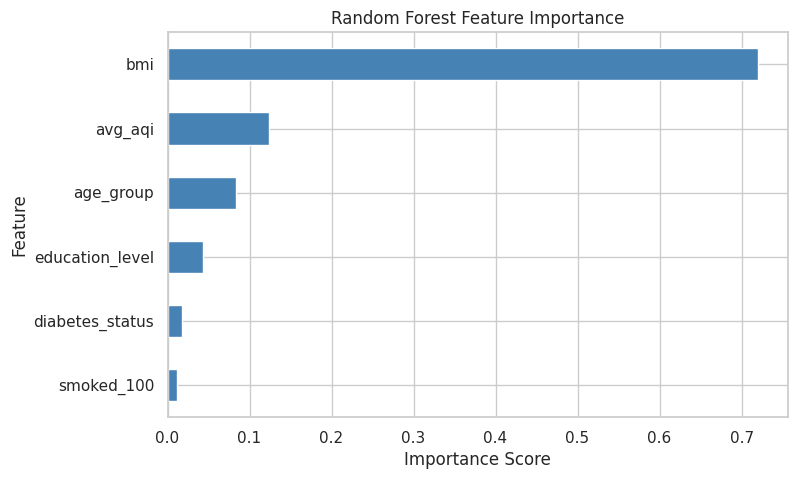

In [18]:
# feature importance
importance = pd.Series(
    rf_model.feature_importances_,
    index = features
)

# sort values
importance = importance.sort_values()

importance.to_frame(name="importance").reset_index().rename(
    columns={"index": "feature"}
).to_csv("feature_importance.csv", index=False)

# plot
plt.figure(figsize = (8, 5))

importance.plot(kind = "barh", color = "steelblue")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

#### **Interpretation of Feature Importance**

The random forest model suggests that BMI is the strongest predictor of reported cognitive impairment in this dataset, contributing substantially more than the other variables.

AQI shows moderate importance relative to the remaining predictors, while age group and education level contribute smaller but noticeable effects. 

Smoking history and diabetes status appear to contribute comparatively little predictive information within this model.

These findings suggest several important points:
- cognitive impairment is likely influenced by broader health conditions and overall physical health status
- environmental exposure may still contribute meaningful information at the population level
- AQI appears more informative than some traditional health indicators in this specific modeling setup
- state-level environmental conditions may capture broader regional health patterns not fully represented by individual variables alone

At the same time, feature importance does not imply causation. The results reflect predictive contribution with this dataset rather than direct biological or cognitive effects.

---

## **Conclusion**

This notebook extends the project's investigation of environmental exposure and cognitive health using an external validation dataset based on BRFSS survey responses and EPA AQI measurements.

Unlike the previous NHANES analyses: 
- the outcome variable in this notebook was self-reported cognitive impairment rather than DSST cognitive test performance
- environmental exposure was measured using state-level average AQI values
- the analysis focused on ecological population-level associations rather than individual causal inference

Overall, the results showed only a weak relationship between AQI and cognitive impairment rates across states. While AQI contributed some predictive information, demographic and health-related variables (especially BMI) appeared to play a larger role in model performance. 

These findings support the broader project narrative that cognitive health is multifactorial and may relate to both environmental and individual health factors. 

### **Limitations**

- BRFSS cognitive impairment measures are self-reported rather than clinically assessed
- AQI was aggregated at the state level, limiting the precision of environmental exposure estimates
- the analysis is cross-sectional and observational, so causal conclusions cannot be made
- model accuracy may be influenced by class imbalance in the target variable

### **Future Work**

Future analyses could:
- incorporate finer geographic exposure measures
- explore longitudinal environmental trends
- apply additional methods for handling imbalanced classification problems
- integrate individual-level environmental exposure data when available

Together, these three notebooks provide complementary perspectives on how environmental and health-related factors may relate to cognitive outcomes across both individual and population levels.

---